In [1]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [2]:

# Sample data: customers by annual spend and visit frequency
data = {
    'annual_spend': [15000, 18000, 12000, 95000, 88000, 102000, 
                      45000, 47000, 43000, 90000, 20000, 16000],
    'visits_per_month': [2, 3, 1, 15, 14, 16, 
                          7, 8, 6, 15, 2, 3]
}
df = pd.DataFrame(data)


In [3]:

# Scale the features (important for K-Means!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


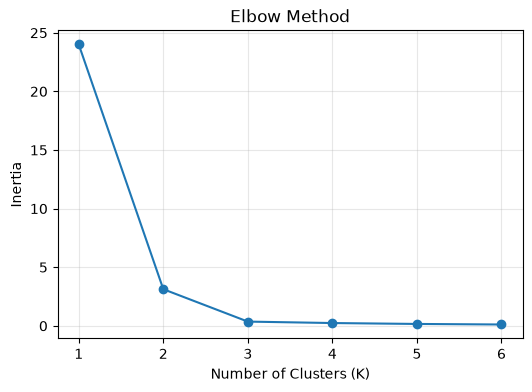

In [4]:

# Elbow method: find the best K
inertia = []
K_range = range(1, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.grid(True, alpha=0.3)
# plt.savefig('elbow_plot.png', dpi=150, bbox_inches='tight')
plt.show()


In [5]:

# Train K-Means with chosen K (e.g., 3 based on elbow plot)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(df)


    annual_spend  visits_per_month  cluster
0          15000                 2        1
1          18000                 3        1
2          12000                 1        1
3          95000                15        0
4          88000                14        0
5         102000                16        0
6          45000                 7        2
7          47000                 8        2
8          43000                 6        2
9          90000                15        0
10         20000                 2        1
11         16000                 3        1


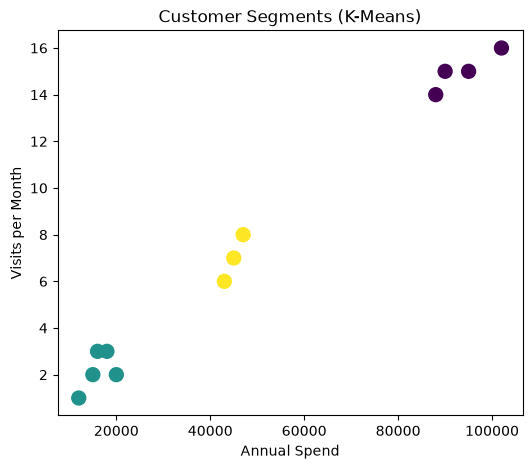

In [6]:

# Visualize the clusters
plt.figure(figsize=(6, 5))
plt.scatter(df['annual_spend'], df['visits_per_month'], 
            c=df['cluster'], cmap='viridis', s=100)
plt.xlabel('Annual Spend')
plt.ylabel('Visits per Month')
plt.title('Customer Segments (K-Means)')
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()